# Model 1: EfficientNet-B0 Baseline (Separate Models)

## Setup & Imports

In [1]:
%pip install -q albumentations

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import models
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score
)
from tqdm import tqdm

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'PyTorch version: {torch.__version__}')
print(f'Albumentations version: {A.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if hasattr(torch.backends, 'mps'):
    print(f'MPS available: {torch.backends.mps.is_available()}')

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.11.0+cu130
Albumentations version: 2.0.8
CUDA available: True
MPS available: False


## Configuration

In [3]:
# ── TEST MODE ──────────────────────────────────────────────────────────────
# Set TEST_MODE = True for a quick end-to-end check (1-2 minutes).
# Uses only TEST_SAMPLES images per split so the whole notebook completes fast.
TEST_MODE = False
TEST_SAMPLES = 200  # images per split used when TEST_MODE is True
# ───────────────────────────────────────────────────────────────────────────

DATA_DIR = '../data/raw'
MODEL_SAVE_DIR = '../models/model1_efficientnet'
RESULTS_DIR = '../results/model1'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

CROSS_OUT_TYPES = ['SINGLE_LINE', 'DOUBLE_LINE', 'DIAGONAL', 'CROSS', 'WAVE', 'ZIG_ZAG', 'SCRATCH']
CROSS_OUT_LABELS = ['Single-Line', 'Double-Line', 'Diagonal', 'Cross', 'Wave', 'Zig-zag', 'Scratch']
NUM_CLASSES = len(CROSS_OUT_TYPES)

IMG_SIZE = 224
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD = [0.229, 0.224, 0.225]

# These are overridden in test mode
BATCH_SIZE = 16    if TEST_MODE else 64
NUM_EPOCHS = 2     if TEST_MODE else 50

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 5
SCHEDULER_PATIENCE = 3
SCHEDULER_FACTOR = 0.5
NUM_WORKERS = 4  # Set to 4 on Linux/Colab with CUDA. Must be 0 on macOS notebooks.
PIN_MEMORY = True if torch.cuda.is_available() else False

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

if TEST_MODE:
    print('  TEST MODE ENABLED — quick end-to-end check (~1-2 min)')
    print(f'  Samples per split : {TEST_SAMPLES}')
    print(f'  Epochs            : {NUM_EPOCHS}')
    print(f'  Batch size        : {BATCH_SIZE}')
    print('  Set TEST_MODE = False for full GPU training.')
else:
    print('FULL TRAINING MODE')
print(f'Device: {DEVICE} | Batch: {BATCH_SIZE} | Epochs: {NUM_EPOCHS}')
print(f'Data directory: {os.path.abspath(DATA_DIR)}')

FULL TRAINING MODE
Device: cuda | Batch: 64 | Epochs: 50
Data directory: /project/crossout-detection/data/raw


## Dataset & DataLoaders

In [4]:
# Augmentation pipeline

train_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Rotate(limit=10, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.5),
    A.Affine(translate_percent={'x': 0.05, 'y': 0.05}, p=0.5),
    A.ElasticTransform(alpha=1, sigma=50, p=0.3),
    A.OneOf([
        A.Morphological(scale=(2, 3), operation='dilation'),
        A.Morphological(scale=(2, 3), operation='erosion'),
    ], p=0.2),
    A.Normalize(mean=IMG_MEAN, std=IMG_STD),
    ToTensorV2(),
])

val_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMG_MEAN, std=IMG_STD),
    ToTensorV2(),
])

In [5]:
class CrossOutDataset(Dataset):
    """Dataset for cross-out detection and classification."""

    def __init__(self, data_dir, split='train', task='binary', transform=None):
        self.data_dir = os.path.join(data_dir, split, 'images')
        self.task = task
        self.transform = transform
        self.images = []
        self.labels = []

        if task == 'binary':
            self._load_binary()
        elif task == 'multiclass':
            self._load_multiclass()

    def _load_binary(self):
        # Clean images -> label 0
        clean_dir = os.path.join(self.data_dir, 'CLEAN')
        if os.path.exists(clean_dir):
            for fname in os.listdir(clean_dir):
                if self._is_image(fname):
                    self.images.append(os.path.join(clean_dir, fname))
                    self.labels.append(0)

        # Cross-out images -> label 1 (all 7 types + MIXED)
        # MIXED is included because in real deployment the model will encounter
        # cross-outs that don't fit a single clean pattern.
        binary_folders = CROSS_OUT_TYPES + ['MIXED']
        for cross_type in binary_folders:
            type_dir = os.path.join(self.data_dir, cross_type)
            if os.path.exists(type_dir):
                for fname in os.listdir(type_dir):
                    if self._is_image(fname):
                        self.images.append(os.path.join(type_dir, fname))
                        self.labels.append(1)

    def _load_multiclass(self):
        # MIXED is excluded here — no per-image type label available
        for idx, cross_type in enumerate(CROSS_OUT_TYPES):
            type_dir = os.path.join(self.data_dir, cross_type)
            if os.path.exists(type_dir):
                for fname in os.listdir(type_dir):
                    if self._is_image(fname):
                        self.images.append(os.path.join(type_dir, fname))
                        self.labels.append(idx)

    def _is_image(self, fname):
        return fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Albumentations requires numpy array (not PIL Image)
        image = np.array(Image.open(self.images[idx]).convert('RGB'))
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image=image)['image']
        return image, label

In [6]:
def get_dataloaders(task):
    train_ds = CrossOutDataset(DATA_DIR, split='train', task=task, transform=train_transforms)
    val_ds   = CrossOutDataset(DATA_DIR, split='val',   task=task, transform=val_transforms)
    test_ds  = CrossOutDataset(DATA_DIR, split='test',  task=task, transform=val_transforms)

    # TEST MODE: shrink each split to TEST_SAMPLES images for a quick run
    if TEST_MODE:
        rng = np.random.default_rng(SEED)
        train_ds = Subset(train_ds, rng.choice(len(train_ds), min(TEST_SAMPLES, len(train_ds)), replace=False).tolist())
        val_ds   = Subset(val_ds,   rng.choice(len(val_ds),   min(TEST_SAMPLES, len(val_ds)),   replace=False).tolist())
        test_ds  = Subset(test_ds,  rng.choice(len(test_ds),  min(TEST_SAMPLES, len(test_ds)),  replace=False).tolist())

    # For binary task: use weighted sampler to handle class imbalance (1:7 ratio)
    train_sampler = None
    shuffle = True
    if task == 'binary':
        # Extract labels from the (possibly subsetted) dataset
        if isinstance(train_ds, Subset):
            labels = np.array([train_ds.dataset.labels[i] for i in train_ds.indices])
        else:
            labels = np.array(train_ds.labels)

        class_counts = np.bincount(labels)
        class_weights = 1.0 / class_counts
        sample_weights = class_weights[labels]
        train_sampler = WeightedRandomSampler(
            weights=sample_weights, num_samples=len(train_ds), replacement=True
        )
        shuffle = False  # sampler handles shuffling

        print(f'  Binary class distribution: Clean={class_counts[0]:,}, Crossed-out={class_counts[1]:,}')
        print(f'  Using WeightedRandomSampler to balance classes')

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                              sampler=train_sampler, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

    print(f'Task: {task}  {"[TEST MODE]" if TEST_MODE else ""}')
    print(f'  Train: {len(train_ds):,} images')
    print(f'  Val:   {len(val_ds):,} images')
    print(f'  Test:  {len(test_ds):,} images')

    return train_loader, val_loader, test_loader

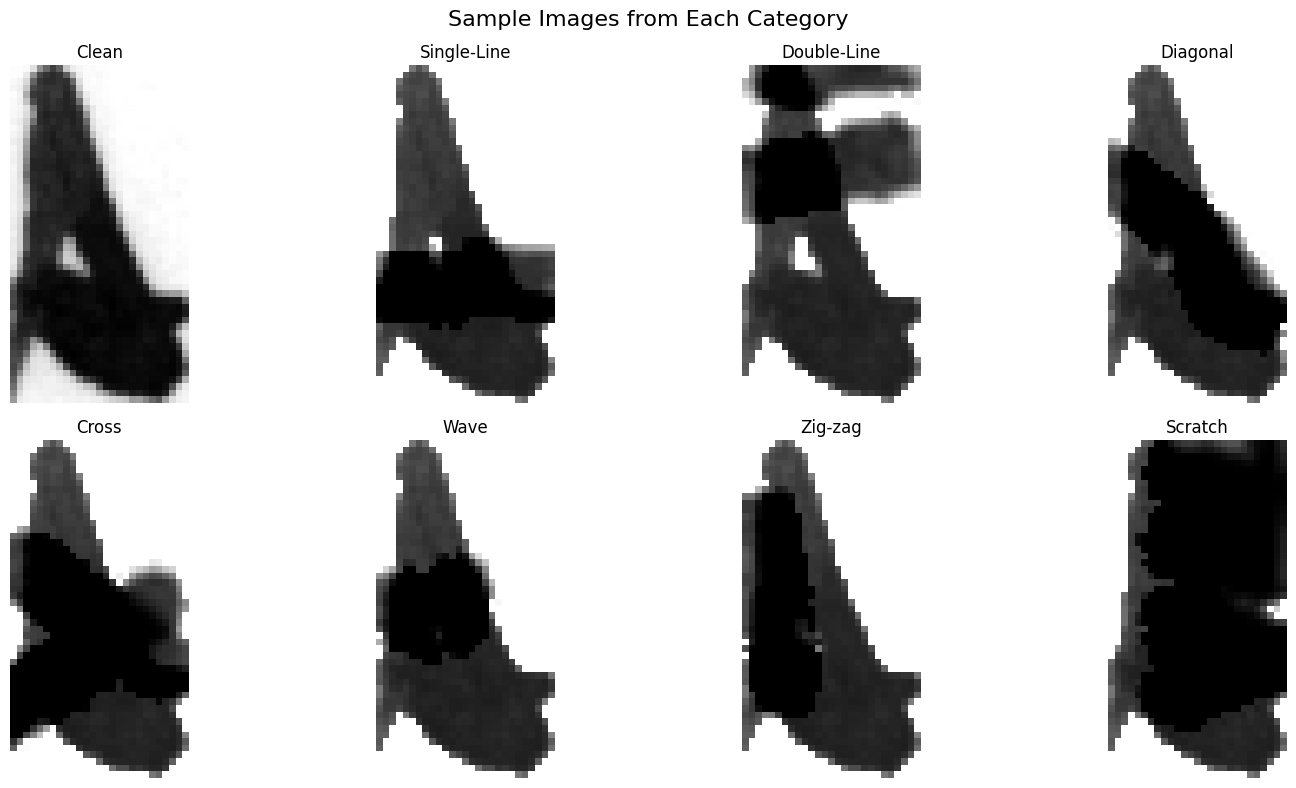

In [7]:
# Show sample images from each cross-out type
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
folders = ['CLEAN'] + CROSS_OUT_TYPES
labels = ['Clean'] + CROSS_OUT_LABELS

for i, (folder, label) in enumerate(zip(folders[:8], labels[:8])):
    ax = axes[i // 4][i % 4]
    img_dir = os.path.join(DATA_DIR, 'train', 'images', folder)
    if os.path.exists(img_dir):
        img_name = sorted(os.listdir(img_dir))[0]
        img = Image.open(os.path.join(img_dir, img_name))
        ax.imshow(img, cmap='gray')
    ax.set_title(label, fontsize=12)
    ax.axis('off')

plt.suptitle('Sample Images from Each Category', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sample_images.png'), dpi=150)
plt.show()

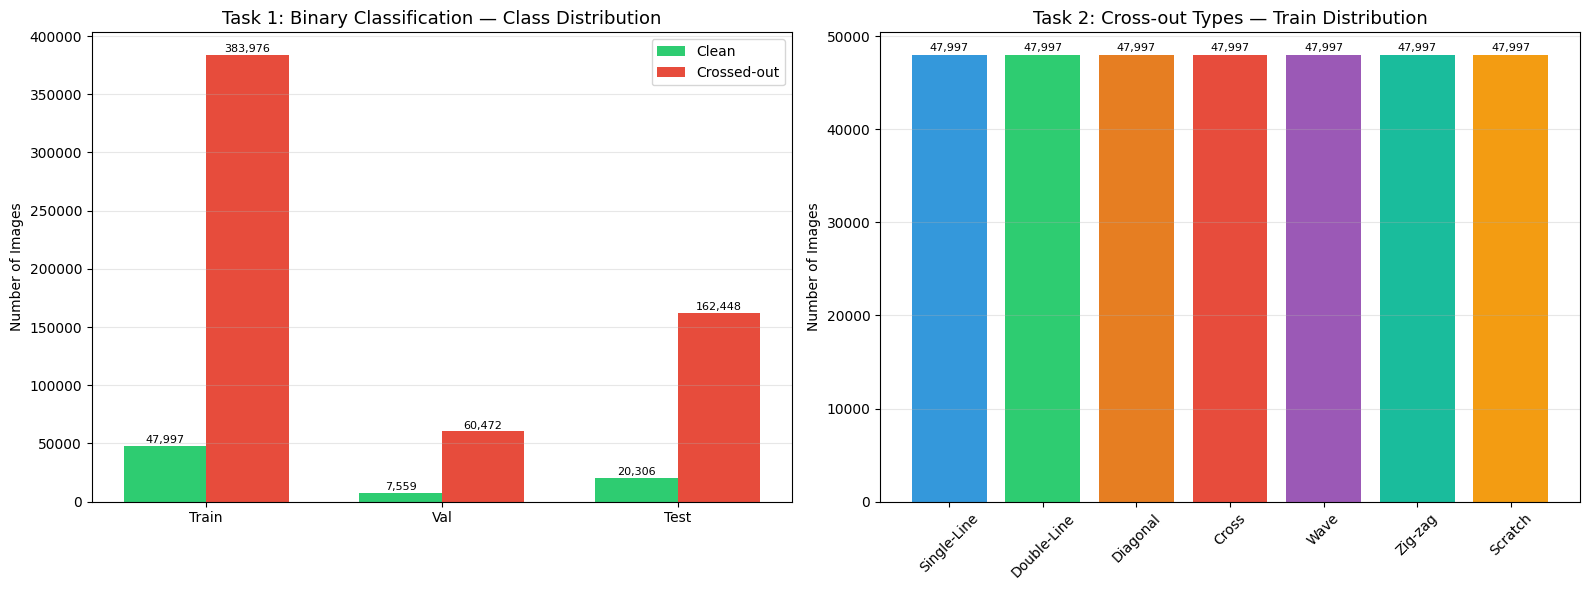


Binary Task — Train split (includes MIXED):
  Clean:         47,997  (11.1%)
  Crossed-out:  383,976  (88.9%)  [7 types + MIXED]
  Imbalance ratio: 1 : 8.0

Multiclass Task — Train split (MIXED excluded, no type label):
  Single-Line :   47,997
  Double-Line :   47,997
  Diagonal    :   47,997
  Cross       :   47,997
  Wave        :   47,997
  Zig-zag     :   47,997
  Scratch     :   47,997
  All types balanced: True


In [8]:
# ── Dataset Distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Binary classification distribution (includes MIXED in crossed-out) ---
binary_data = {'Clean': [], 'Crossed-out': []}
for split in ['train', 'val', 'test']:
    clean_dir = os.path.join(DATA_DIR, split, 'images', 'CLEAN')
    clean_count = len([f for f in os.listdir(clean_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]) if os.path.exists(clean_dir) else 0
    cross_count = 0
    for ct in CROSS_OUT_TYPES + ['MIXED']:
        ct_dir = os.path.join(DATA_DIR, split, 'images', ct)
        if os.path.exists(ct_dir):
            cross_count += len([f for f in os.listdir(ct_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    binary_data['Clean'].append(clean_count)
    binary_data['Crossed-out'].append(cross_count)

x = np.arange(3)
width = 0.35
bars1 = axes[0].bar(x - width/2, binary_data['Clean'], width, label='Clean', color='#2ecc71')
bars2 = axes[0].bar(x + width/2, binary_data['Crossed-out'], width, label='Crossed-out', color='#e74c3c')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Train', 'Val', 'Test'])
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Task 1: Binary Classification — Class Distribution', fontsize=13)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

# --- Cross-out type distribution (train split) ---
type_counts = []
for ct in CROSS_OUT_TYPES:
    ct_dir = os.path.join(DATA_DIR, 'train', 'images', ct)
    count = len([f for f in os.listdir(ct_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]) if os.path.exists(ct_dir) else 0
    type_counts.append(count)

colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c', '#9b59b6', '#1abc9c', '#f39c12']
bars = axes[1].bar(CROSS_OUT_LABELS, type_counts, color=colors)
axes[1].set_ylabel('Number of Images')
axes[1].set_title('Task 2: Cross-out Types — Train Distribution', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'dataset_distribution.png'), dpi=150)
plt.show()

# Print summary
total_binary = binary_data['Clean'][0] + binary_data['Crossed-out'][0]
print(f'\nBinary Task — Train split (includes MIXED):')
print(f'  Clean:       {binary_data["Clean"][0]:>8,}  ({binary_data["Clean"][0]/total_binary*100:.1f}%)')
print(f'  Crossed-out: {binary_data["Crossed-out"][0]:>8,}  ({binary_data["Crossed-out"][0]/total_binary*100:.1f}%)  [7 types + MIXED]')
print(f'  Imbalance ratio: 1 : {binary_data["Crossed-out"][0] / binary_data["Clean"][0]:.1f}')
print(f'\nMulticlass Task — Train split (MIXED excluded, no type label):')
for label, count in zip(CROSS_OUT_LABELS, type_counts):
    print(f'  {label:<12}: {count:>8,}')
print(f'  All types balanced: {len(set(type_counts)) == 1}')

## Model Architecture

In [9]:
class EfficientNetClassifier(nn.Module):
    """EfficientNet-B0 for single-task classification."""

    def __init__(self, num_classes=1):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_features = self.backbone.classifier[1].in_features  # 1280
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.2),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

    def get_backbone_state_dict(self):
        return self.backbone.features.state_dict()

# Quick check
model_test = EfficientNetClassifier(num_classes=1)
total_params = sum(p.numel() for p in model_test.parameters())
trainable_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
del model_test

Total parameters: 4,008,829
Trainable parameters: 4,008,829


## Training Functions

In [10]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_loss = None

    def __call__(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            return False
        self.counter += 1
        if self.counter >= self.patience:
            print(f'Early stopping triggered after {self.counter} epochs without improvement.')
            return True
        return False

In [11]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, task, scaler=None):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    use_amp = scaler is not None

    for images, labels in tqdm(dataloader, desc='Training', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(images)
            if task == 'binary':
                outputs = outputs.squeeze(1)
                loss = criterion(outputs, labels.float())
            else:
                loss = criterion(outputs, labels)

        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        with torch.no_grad():
            if task == 'binary':
                preds = (torch.sigmoid(outputs) > 0.5).long()
            else:
                preds = outputs.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def validate(model, dataloader, criterion, device, task, use_amp=False):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Validating', leave=False):
            images, labels = images.to(device), labels.to(device)

            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(images)
                if task == 'binary':
                    outputs = outputs.squeeze(1)
                    loss = criterion(outputs, labels.float())
                    preds = (torch.sigmoid(outputs) > 0.5).long()
                else:
                    loss = criterion(outputs, labels)
                    preds = outputs.argmax(dim=1)

            running_loss += loss.item() * images.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [12]:
def train_model(model, train_loader, val_loader, task, save_path, model_name='model1'):
    device = torch.device(DEVICE)
    model = model.to(device)

    criterion = nn.BCEWithLogitsLoss() if task == 'binary' else nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=SCHEDULER_PATIENCE, factor=SCHEDULER_FACTOR)
    early_stopping = EarlyStopping(patience=EARLY_STOPPING_PATIENCE)

    # Mixed precision: only on CUDA (not supported on MPS/CPU)
    use_amp = (DEVICE == 'cuda')
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp) if use_amp else None
    if use_amp:
        print('Mixed precision (AMP) enabled — ~1.5-2x faster on CUDA')

    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    best_val_loss = float('inf')
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f'\nTraining {model_name} - Task: {task}')
    print(f'Device: {device}')
    print(f'Epochs: {NUM_EPOCHS} | Batch: {BATCH_SIZE} | LR: {LEARNING_RATE}')
    print('-' * 60)

    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, task, scaler=scaler)
        val_loss, val_acc = validate(model, val_loader, criterion, device, task, use_amp=use_amp)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        lr = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | LR: {lr:.6f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(f'  -> Best model saved')

        if early_stopping(val_loss):
            break

    print(f'\nTraining complete. Best Val Loss: {best_val_loss:.4f}')

    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    return model, history

## Evaluation Functions

In [13]:
def get_predictions(model, dataloader, task):
    device = torch.device(DEVICE)
    use_amp = (DEVICE == 'cuda')
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Evaluating', leave=False):
            images = images.to(device)

            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(images)

            if task == 'binary':
                probs = torch.sigmoid(outputs.squeeze(1)).cpu().numpy()
                preds = (probs > 0.5).astype(int)
            else:
                probs = torch.softmax(outputs, dim=1).cpu().numpy()
                preds = outputs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            all_probs.extend(probs)

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [14]:
def plot_confusion_matrix(cm, class_names, title):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title, fontsize=14)
    plt.colorbar(im)

    tick_marks = np.arange(len(class_names))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(class_names)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black')

    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.tight_layout()
    return fig


def plot_training_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history['train_acc'], label='Train Acc')
    ax2.plot(history['val_acc'], label='Val Acc')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

## Task 1: Binary Classification (Clean vs Crossed-out)

In [ ]:
train_loader_t1, val_loader_t1, test_loader_t1 = get_dataloaders(task='binary')
model_t1 = EfficientNetClassifier(num_classes=1)
task1_save_path = os.path.join(MODEL_SAVE_DIR, 'task1_best.pth')

model_t1, history_t1 = train_model(
    model_t1, train_loader_t1, val_loader_t1,
    task='binary', save_path=task1_save_path, model_name='model1'
)
fig = plot_training_history(history_t1, 'Task 1: Binary Classification')
fig.savefig(os.path.join(RESULTS_DIR, 'task1_training_curves.png'), dpi=150)
plt.show()

  Binary class distribution: Clean=47,997, Crossed-out=383,976
  Using WeightedRandomSampler to balance classes
Task: binary  
  Train: 431,973 images
  Val:   68,031 images
  Test:  182,754 images


/tmp/ipykernel_252328/57076304.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp) if use_amp else None


Mixed precision (AMP) enabled — ~1.5-2x faster on CUDA

Training model1 - Task: binary
Device: cuda
Epochs: 50 | Batch: 64 | LR: 0.0001
------------------------------------------------------------


Training:   0%|          | 0/6750 [00:00<?, ?it/s]/tmp/ipykernel_252328/3089550800.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Validating:   0%|          | 0/1063 [00:00<?, ?it/s]/tmp/ipykernel_252328/3089550800.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
                                                               

Epoch [1/50] Train Loss: 0.0757 Acc: 0.9504 | Val Loss: 0.0773 Acc: 0.9526 | LR: 0.000100
  -> Best model saved


...

Epoch [6/50] Train Loss: 0.0670 Acc: 0.9524 | Val Loss: 0.0767 Acc: 0.9830 | LR: 0.000100


Epoch [7/50] Train Loss: 0.0672 Acc: 0.9526 | Val Loss: 0.0805 Acc: 0.9029 | LR: 0.000100


Epoch [8/50] Train Loss: 0.0670 Acc: 0.9523 | Val Loss: 0.0807 Acc: 0.9836 | LR: 0.000100


Epoch [9/50] Train Loss: 0.0668 Acc: 0.9524 | Val Loss: 0.0854 Acc: 0.9031 | LR: 0.000050


Training:  99%|█████████▊| 6655/6750 [13:20<00:11,  8.61it/s]

### Evaluate on Test Set

In [16]:
labels_t1, preds_t1, probs_t1 = get_predictions(model_t1, test_loader_t1, task='binary')

results_t1 = {
    'accuracy': accuracy_score(labels_t1, preds_t1),
    'f1_score': f1_score(labels_t1, preds_t1),
    'precision': precision_score(labels_t1, preds_t1),
    'recall': recall_score(labels_t1, preds_t1),
    'auc_roc': roc_auc_score(labels_t1, probs_t1),
}

print('=== Task 1: Binary Classification Results ===')
for metric, value in results_t1.items():
    print(f'  {metric}: {value:.4f}')

=== Task 1: Binary Classification Results ===
  accuracy: 0.9864
  f1_score: 0.9924
  precision: 0.9879
  recall: 0.9970
  auc_roc: 0.9949


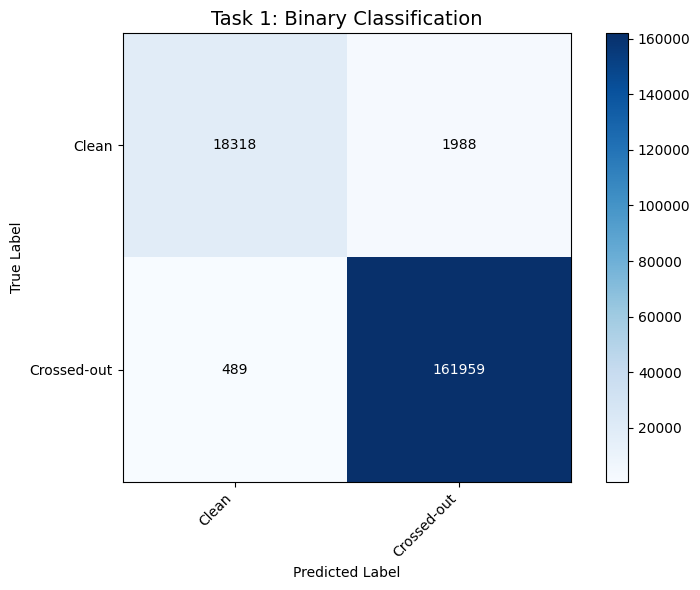

In [17]:
cm_t1 = confusion_matrix(labels_t1, preds_t1)
fig = plot_confusion_matrix(cm_t1, ['Clean', 'Crossed-out'], 'Task 1: Binary Classification')
fig.savefig(os.path.join(RESULTS_DIR, 'task1_confusion_matrix.png'), dpi=150)
plt.show()

## Task 2: Multi-class Classification (7 Cross-out Types)

/tmp/ipykernel_252328/57076304.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp) if use_amp else None


Task: multiclass  
  Train: 335,979 images
  Val:   52,913 images
  Test:  142,142 images
Mixed precision (AMP) enabled — ~1.5-2x faster on CUDA

Training model1 - Task: multiclass
Device: cuda
Epochs: 50 | Batch: 64 | LR: 0.0001
------------------------------------------------------------


Training:   0%|          | 0/5250 [00:00<?, ?it/s]/tmp/ipykernel_252328/3089550800.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Training:  63%|██████▎   | 3316/5250 [06:35<04:14,  7.61it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

                                                             

Epoch [7/50] Train Loss: 0.1990 Acc: 0.9129 | Val Loss: 0.2284 Acc: 0.9005 | LR: 0.000100


Epoch [9/50] Train Loss: 0.1966 Acc: 0.9143 | Val Loss: 0.2279 Acc: 0.9009 | LR: 0.000100


...

Epoch [11/50] Train Loss: 0.1949 Acc: 0.9149 | Val Loss: 0.2274 Acc: 0.9010 | LR: 0.000100


Epoch [12/50] Train Loss: 0.1942 Acc: 0.9150 | Val Loss: 0.2279 Acc: 0.9014 | LR: 0.000100


Epoch [13/50] Train Loss: 0.1936 Acc: 0.9157 | Val Loss: 0.2276 Acc: 0.9011 | LR: 0.000100


Epoch [14/50] Train Loss: 0.1930 Acc: 0.9156 | Val Loss: 0.2282 Acc: 0.9012 | LR: 0.000050


Epoch [15/50] Train Loss: 0.1898 Acc: 0.9165 | Val Loss: 0.2268 Acc: 0.9020 | LR: 0.000050
Early stopping triggered after 5 epochs without improvement.

Training complete. Best Val Loss: 0.2261


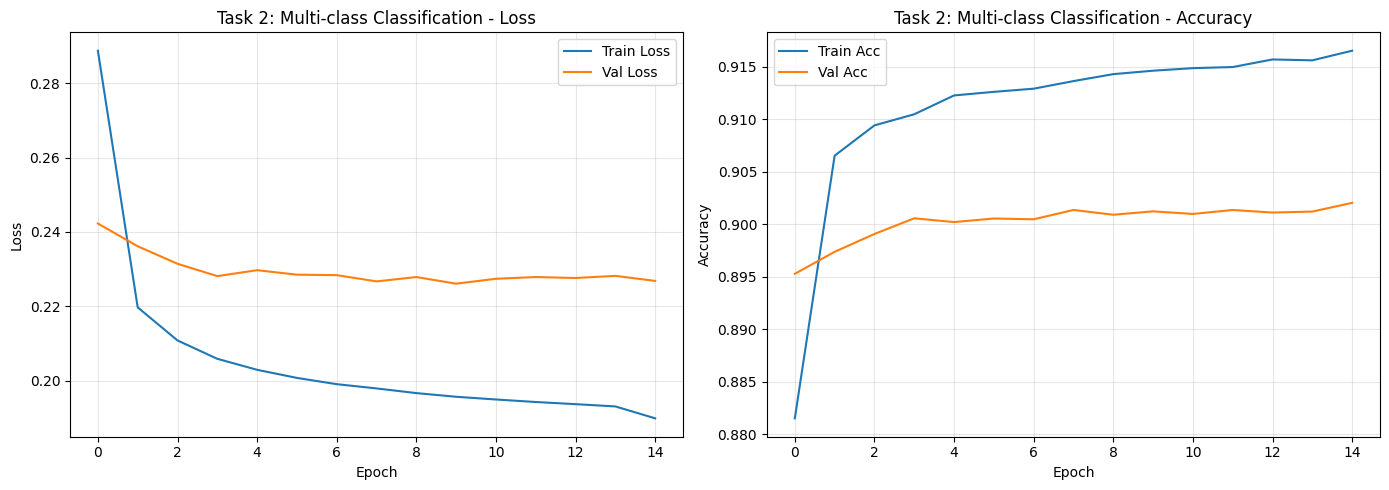

In [18]:
train_loader_t2, val_loader_t2, test_loader_t2 = get_dataloaders(task='multiclass')
model_t2 = EfficientNetClassifier(num_classes=NUM_CLASSES)
task2_save_path = os.path.join(MODEL_SAVE_DIR, 'task2_best.pth')

model_t2, history_t2 = train_model(
    model_t2, train_loader_t2, val_loader_t2,
    task='multiclass', save_path=task2_save_path, model_name='model1'
)
fig = plot_training_history(history_t2, 'Task 2: Multi-class Classification')
fig.savefig(os.path.join(RESULTS_DIR, 'task2_training_curves.png'), dpi=150)
plt.show()

### Evaluate on Test Set

In [19]:
labels_t2, preds_t2, probs_t2 = get_predictions(model_t2, test_loader_t2, task='multiclass')

results_t2 = {
    'accuracy': accuracy_score(labels_t2, preds_t2),
    'macro_f1': f1_score(labels_t2, preds_t2, average='macro'),
    'macro_precision': precision_score(labels_t2, preds_t2, average='macro'),
    'macro_recall': recall_score(labels_t2, preds_t2, average='macro'),
}

print('=== Task 2: Multi-class Classification Results ===')
for metric, value in results_t2.items():
    print(f'  {metric}: {value:.4f}')

print('\nPer-class Report:')
print(classification_report(labels_t2, preds_t2, target_names=CROSS_OUT_LABELS))

Evaluating:   0%|          | 0/2221 [00:00<?, ?it/s]/tmp/ipykernel_252328/3640988131.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
                                                               

=== Task 2: Multi-class Classification Results ===
  accuracy: 0.9091
  macro_f1: 0.9171
  macro_precision: 0.9419
  macro_recall: 0.9091

Per-class Report:
              precision    recall  f1-score   support

 Single-Line       0.99      0.90      0.94     20306
 Double-Line       1.00      0.89      0.94     20306
    Diagonal       1.00      0.90      0.95     20306
       Cross       1.00      0.90      0.95     20306
        Wave       0.99      0.89      0.94     20306
     Zig-zag       0.62      0.99      0.76     20306
     Scratch       1.00      0.90      0.95     20306

    accuracy                           0.91    142142
   macro avg       0.94      0.91      0.92    142142
weighted avg       0.94      0.91      0.92    142142



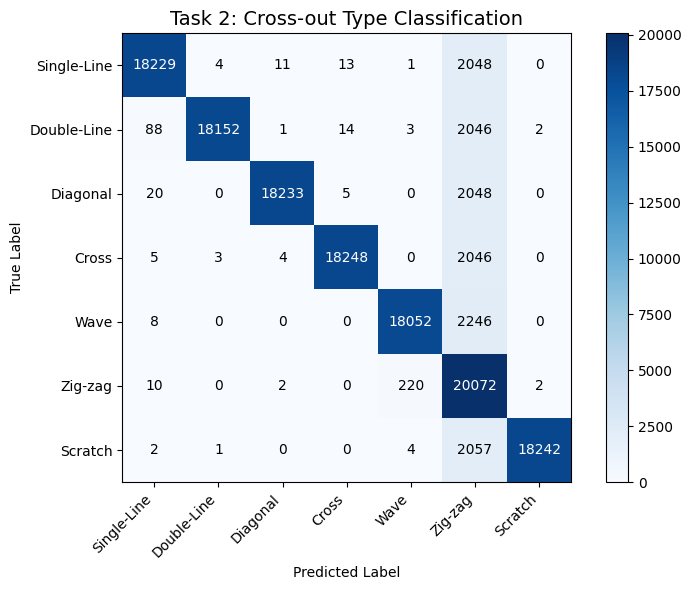

In [20]:
cm_t2 = confusion_matrix(labels_t2, preds_t2)
fig = plot_confusion_matrix(cm_t2, CROSS_OUT_LABELS, 'Task 2: Cross-out Type Classification')
fig.savefig(os.path.join(RESULTS_DIR, 'task2_confusion_matrix.png'), dpi=150)
plt.show()

### Save Backbone Weights (for other Models)

In [21]:
# Save both backbones with metadata
backbone_t1_path = os.path.join(MODEL_SAVE_DIR, 'backbone_task1_2.pth')
backbone_t2_path = os.path.join(MODEL_SAVE_DIR, 'backbone_task2_2.pth')
backbone_default_path = os.path.join(MODEL_SAVE_DIR, 'backbone.pth')

# Save with metadata so Model 2/3 know exactly what they're loading
def save_checkpoint(state_dict, path, metadata):
    checkpoint = {
        'state_dict': state_dict,
        'architecture': 'EfficientNet-B0',
        'img_size': IMG_SIZE,
        'img_mean': IMG_MEAN,
        'img_std': IMG_STD,
        **metadata
    }
    torch.save(checkpoint, path)

save_checkpoint(model_t1.get_backbone_state_dict(), backbone_t1_path,
    {'source_task': 'binary', 'source_accuracy': results_t1['accuracy']})

save_checkpoint(model_t2.get_backbone_state_dict(), backbone_t2_path,
    {'source_task': 'multiclass', 'source_accuracy': results_t2['accuracy']})

save_checkpoint(model_t1.get_backbone_state_dict(), backbone_default_path,
    {'source_task': 'binary (default)', 'source_accuracy': results_t1['accuracy']})

# Also save full task models with metadata
torch.save({
    'state_dict': model_t1.state_dict(),
    'architecture': 'EfficientNet-B0', 'task': 'binary',
    'num_classes': 1, 'results': results_t1,
    'img_size': IMG_SIZE, 'img_mean': IMG_MEAN, 'img_std': IMG_STD,
}, os.path.join(MODEL_SAVE_DIR, 'task1_final.pth'))

torch.save({
    'state_dict': model_t2.state_dict(),
    'architecture': 'EfficientNet-B0', 'task': 'multiclass',
    'num_classes': NUM_CLASSES, 'class_names': CROSS_OUT_LABELS, 'results': results_t2,
    'img_size': IMG_SIZE, 'img_mean': IMG_MEAN, 'img_std': IMG_STD,
}, os.path.join(MODEL_SAVE_DIR, 'task2_final.pth'))

print('Backbone weights saved (with metadata):')
print(f'  Task 1 backbone: {backbone_t1_path}')
print(f'  Task 2 backbone: {backbone_t2_path}')
print(f'  Default (Task 1): {backbone_default_path}')
print(f'\nFull model checkpoints:')
print(f'  {MODEL_SAVE_DIR}/task1_final.pth')
print(f'  {MODEL_SAVE_DIR}/task2_final.pth')
print('\nModel 2/3 can load backbone with:')
print("  checkpoint = torch.load('backbone.pth')")
print("  model.backbone.features.load_state_dict(checkpoint['state_dict'])")

Backbone weights saved (with metadata):
  Task 1 backbone: ../models/model1_efficientnet/backbone_task1_2.pth
  Task 2 backbone: ../models/model1_efficientnet/backbone_task2_2.pth
  Default (Task 1): ../models/model1_efficientnet/backbone.pth

Full model checkpoints:
  ../models/model1_efficientnet/task1_final.pth
  ../models/model1_efficientnet/task2_final.pth

Model 2/3 can load backbone with:
  checkpoint = torch.load('backbone.pth')
  model.backbone.features.load_state_dict(checkpoint['state_dict'])
